## What to do step by step

In [67]:
# ============================================================
# SETUP & PATHS
# ============================================================
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [68]:
# ── Paths ────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('../../').resolve()
DATA_DIR     = NOTEBOOK_DIR / 'data'
RAW_DIR      = DATA_DIR / 'raw'
AVL_DIR      = RAW_DIR / 'avl' / 'stop_level'
GTFS_DIR     = RAW_DIR / 'gtfs' / 'gtfs_merged_29_39'
DB_PATH      = str(DATA_DIR / 'ttc_analysis.duckdb')

ROUTE        = 29
AVL_CSVS     = sorted(AVL_DIR.joinpath(str(ROUTE)).glob('*.csv'))

In [69]:
print(f"DB path   : {DB_PATH}")
print(f"CSVs found: {len(AVL_CSVS)}")
for f in AVL_CSVS:
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

DB path   : /Users/sacharavya/Desktop/ttc-delay-analysis/data/ttc_analysis.duckdb
CSVs found: 12
  202501_rt29.csv  (223.4 MB)
  202502_rt29.csv  (200.1 MB)
  202503_rt29.csv  (223.5 MB)
  202504_rt29.csv  (217.4 MB)
  202505_rt29.csv  (221.5 MB)
  202506_rt29.csv  (200.0 MB)
  202507_rt29.csv  (202.6 MB)
  202508_rt29.csv  (213.1 MB)
  202509_rt29.csv  (246.3 MB)
  202510_rt29.csv  (230.0 MB)
  202511_rt29.csv  (206.0 MB)
  202512_rt29.csv  (210.9 MB)


### PHASE 1: LOAD AVL CSVs → DUCKDB BRONZE

In [70]:

# Columns have NO header in the raw files
COL_NAMES = ['date', 'time_sec', 'vehicle_id', 'route', 'run',
             'lat', 'lon', 'trip_id', 'loading']
COL_TYPES = {
    'date':       'INTEGER',
    'time_sec':   'INTEGER',
    'vehicle_id': 'INTEGER',
    'route':      'INTEGER',
    'run':        'INTEGER',
    'lat':        'DOUBLE',
    'lon':        'DOUBLE',
    'trip_id':    'INTEGER',
    'loading':    'VARCHAR',
}

con = duckdb.connect(DB_PATH)

In [71]:

# Build a UNION ALL query over all 12 CSVs using DuckDB's native CSV reader
# DuckDB can read CSVs directly — no need to load into Python memory
csv_paths = [str(p) for p in AVL_CSVS]

# Drop + recreate bronze table
con.execute("DROP TABLE IF EXISTS bronze_avl_29")

In [72]:
union_parts = []
for path in csv_paths:
    union_parts.append(f"""
    SELECT
        column0::INTEGER  AS date,
        column1::INTEGER  AS time_sec,
        column2::INTEGER  AS vehicle_id,
        column3::INTEGER  AS route,
        column4::INTEGER  AS run,
        column5::DOUBLE   AS lat,
        column6::DOUBLE   AS lon,
        column7::INTEGER  AS trip_id,
        column8::VARCHAR  AS loading
    FROM read_csv('{path}', header=false, columns={{
        'column0': 'VARCHAR', 'column1': 'VARCHAR', 'column2': 'VARCHAR',
        'column3': 'VARCHAR', 'column4': 'VARCHAR', 'column5': 'VARCHAR',
        'column6': 'VARCHAR', 'column7': 'VARCHAR', 'column8': 'VARCHAR'
    }})
    """)

full_query = " UNION ALL ".join(union_parts)

con.execute(f"""
    CREATE TABLE bronze_avl_29 AS
    {full_query}
""")

In [73]:
count = con.execute("SELECT COUNT(*) FROM bronze_avl_29").fetchone()[0]
print(f"✓ bronze_avl_29 loaded: {count:,} rows")

✓ bronze_avl_29 loaded: 40,639,432 rows


In [74]:
# Quick sanity check
print("\\nDate range:")
con.execute("""
    SELECT MIN(date), MAX(date), COUNT(DISTINCT vehicle_id), COUNT(DISTINCT trip_id)
    FROM bronze_avl_29
""").df()

\nDate range:


,min(date),max(date),count(DISTINCT vehicle_id),count(DISTINCT trip_id)
0,20250101,20251231,461,15316


In [75]:
# ============================================================
# PHASE 2: GPS OUTLIER REMOVAL
# ============================================================
# Toronto bounding box (generous, covers full TTC service area)
LAT_MIN, LAT_MAX = 43.58,  43.86
LON_MIN, LON_MAX = -79.64, -79.10

In [76]:
# Speed filter: flag teleportation events
# We compute speed between consecutive pings for same vehicle
# Speed = haversine_distance / time_delta → if > 120 km/h, it's a teleport

con.execute("DROP TABLE IF EXISTS bronze_avl_29_clean")

con.execute(f"""
CREATE TABLE bronze_avl_29_clean AS
WITH
-- Step 1: Add a proper datetime and filter bounding box
bounded AS (
    SELECT *,
        -- Reconstruct datetime: date as YYYYMMDD int + time_sec offset
        make_date(
            (date // 10000)::INTEGER,
            ((date % 10000) // 100)::INTEGER,
            (date % 100)::INTEGER
        ) + INTERVAL (time_sec) SECOND  AS observed_at,
        -- Clamp loading to known values
        CASE
            WHEN UPPER(loading) IN ('EMPTY', 'HALF_EMPTY', 'FULL') THEN UPPER(loading)
            ELSE NULL
        END AS loading_clean
    FROM bronze_avl_29
    WHERE lat  BETWEEN {LAT_MIN} AND {LAT_MAX}
      AND lon  BETWEEN {LON_MIN} AND {LON_MAX}
      AND lat  != 0.0
      AND lon  != 0.0
),
-- Step 2: Compute speed between consecutive pings per vehicle
with_prev AS (
    SELECT *,
        LAG(lat)         OVER w AS prev_lat,
        LAG(lon)         OVER w AS prev_lon,
        LAG(time_sec)    OVER w AS prev_time_sec,
        LAG(date)        OVER w AS prev_date
    FROM bounded
    WINDOW w AS (PARTITION BY vehicle_id ORDER BY observed_at)
),
-- Step 3: Haversine speed (km/h) — flag teleports
with_speed AS (
    SELECT *,
        CASE
            WHEN prev_lat IS NULL THEN 0.0
            WHEN (time_sec - prev_time_sec + (date - prev_date) * 86400) <= 0 THEN 0.0
            ELSE
                -- Haversine in km / elapsed seconds * 3600
                (2 * 6371.0 * ASIN(SQRT(
                    POWER(SIN(RADIANS(lat - prev_lat) / 2), 2) +
                    COS(RADIANS(prev_lat)) * COS(RADIANS(lat)) *
                    POWER(SIN(RADIANS(lon - prev_lon) / 2), 2)
                ))) /
                NULLIF(
                    ABS(time_sec - prev_time_sec) +
                    ABS(date - prev_date) * 86400,
                    0
                ) * 3600.0
        END AS speed_kmh
    FROM with_prev
)
SELECT
    date, time_sec, vehicle_id, route, run,
    lat, lon, trip_id, loading_clean AS loading,
    observed_at, speed_kmh,
    -- Flag detour period for Route 29 south-end diversion
    CASE
        WHEN date BETWEEN 20250928 AND 20251029 THEN true
        ELSE false
    END AS is_detour_period
FROM with_speed
WHERE speed_kmh < 120.0   -- remove teleportation events
   OR prev_lat IS NULL     -- keep first ping per vehicle (no prev to compare)
""")

n_before = con.execute("SELECT COUNT(*) FROM bronze_avl_29").fetchone()[0]
n_after  = con.execute("SELECT COUNT(*) FROM bronze_avl_29_clean").fetchone()[0]
removed  = n_before - n_after

In [77]:
print(f"✓ Before cleaning : {n_before:,}")
print(f"✓ After cleaning  : {n_after:,}")
print(f"  Removed          : {removed:,}  ({100*removed/n_before:.2f}%)")
print(f"\\nSpeed distribution (km/h):")
con.execute("""
    SELECT
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY speed_kmh) AS p50,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY speed_kmh) AS p95,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY speed_kmh) AS p99,
        MAX(speed_kmh) AS max_speed
    FROM bronze_avl_29_clean
""").df()

✓ Before cleaning : 40,639,432
✓ After cleaning  : 40,627,126
  Removed          : 12,306  (0.03%)
\nSpeed distribution (km/h):


,p50,p95,p99,max_speed
0,0.00,38.06,45.71,119.97


In [78]:
# ============================================================
# PHASE 4: LOAD GTFS STATIC FILES → DUCKDB
# ============================================================

gtfs_tables = {
    'gtfs_stops':       GTFS_DIR / 'stops.csv',
    'gtfs_stop_times':  GTFS_DIR / 'stop_times.csv',
    'gtfs_trips':       GTFS_DIR / 'trips.csv',
    'gtfs_shapes':      GTFS_DIR / 'shapes.csv',
    'gtfs_calendar':    GTFS_DIR / 'calendar.csv',
    'gtfs_cal_dates':   GTFS_DIR / 'calendar_dates.csv',
    'gtfs_routes':      GTFS_DIR / 'routes.csv',
}

In [79]:
for tbl, path in gtfs_tables.items():
    con.execute(f"DROP TABLE IF EXISTS {tbl}")
    con.execute(f"""
        CREATE TABLE {tbl} AS
        SELECT * FROM read_csv_auto('{path}', header=true)
    """)
    n = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  ✓ {tbl:<22} {n:>10,} rows")

  ✓ gtfs_stops                154,884 rows
  ✓ gtfs_stop_times         5,957,520 rows
  ✓ gtfs_trips                 43,442 rows
  ✓ gtfs_shapes               248,428 rows
  ✓ gtfs_calendar                  66 rows
  ✓ gtfs_cal_dates                 70 rows
  ✓ gtfs_routes                    34 rows


In [80]:
print("\\nGTFS stops sample:")
print(con.execute("SELECT * FROM gtfs_stops LIMIT 3").df().to_string())

print("\\nGTFS trips sample:")
print(con.execute("""
    SELECT trip_id, route_id, service_id, trip_headsign, direction_id, shape_id
    FROM gtfs_trips LIMIT 3
""").df().to_string())

print("\\nGTFS stop_times sample:")
print(con.execute("""
    SELECT trip_id, arrival_time, departure_time, stop_id, stop_sequence
    FROM gtfs_stop_times LIMIT 3
""").df().to_string())

\nGTFS stops sample:
   stop_id stop_code                              stop_name stop_desc  stop_lat  stop_lon zone_id stop_url location_type parent_station stop_timezone  wheelchair_boarding _feed_date
0    42503     16637  Warden Station at Temporary Bus Bay 2      None     43.71    -79.28    None     None          None           None          None                    1        NaT
1     4266     15504          FORT YORK BLVD AT BATHURST ST      None     43.64    -79.40    None     None          None           None          None                    1        NaT
2    42542     16122        Eglinton Ave West at Spadina Rd      None     43.70    -79.42    None     None          None           None          None                    2        NaT
\nGTFS trips sample:
     trip_id  route_id  service_id                               trip_headsign  direction_id   shape_id
0  153519070        29           5  NORTH - 29 DUFFERIN towards WILSON STATION             1  shp-29-02
1  148337040        29

In [81]:
# ============================================================
# PHASES 5-7: MATCH GPS → STOPS → DELAYS
# ============================================================
# Strategy:
#   1. Each AVL ping has a trip_id that joins directly to GTFS trips/stop_times
#   2. For each ping, find the nearest GTFS stop ON THAT TRIP using Haversine
#   3. Arrival time = observed_at; scheduled time = stop_times.arrival_time
#   4. delay_seconds = actual_arrival - scheduled_arrival

con.execute("DROP TABLE IF EXISTS silver_stop_events_29")

con.execute("""
CREATE TABLE silver_stop_events_29 AS
WITH

-- ── 1. Parse GTFS stop_times arrival into seconds from midnight ──────────
-- arrival_time is HH:MM:SS (can exceed 24:00 for overnight trips)
stop_times_secs AS (
    SELECT
        trip_id::INTEGER       AS trip_id,
        stop_id::INTEGER       AS stop_id,
        stop_sequence::INTEGER AS stop_sequence,
        -- Convert HH:MM:SS → seconds from midnight (handles >24h)
        (SPLIT_PART(arrival_time, ':', 1)::INTEGER * 3600 +
         SPLIT_PART(arrival_time, ':', 2)::INTEGER * 60 +
         SPLIT_PART(arrival_time, ':', 3)::INTEGER)  AS scheduled_sec,
        arrival_time
    FROM gtfs_stop_times
),

-- ── 2. Join AVL pings to their GTFS trip's stop list ────────────────────
avl_with_stops AS (
    SELECT
        avl.date,
        avl.time_sec,
        avl.vehicle_id,
        avl.route,
        avl.run,
        avl.lat          AS avl_lat,
        avl.lon          AS avl_lon,
        avl.trip_id,
        avl.loading,
        avl.observed_at,
        avl.speed_kmh,
        avl.is_detour_period,
        st.stop_id,
        st.stop_sequence,
        st.scheduled_sec,
        st.arrival_time,
        gs.stop_lat,
        gs.stop_lon,
        gs.stop_name,
        -- Haversine distance in metres between GPS ping and stop
        2 * 6371000.0 * ASIN(SQRT(
            POWER(SIN(RADIANS(avl.lat - gs.stop_lat::DOUBLE) / 2), 2) +
            COS(RADIANS(gs.stop_lat::DOUBLE)) * COS(RADIANS(avl.lat)) *
            POWER(SIN(RADIANS(avl.lon - gs.stop_lon::DOUBLE) / 2), 2)
        )) AS dist_to_stop_m
    FROM bronze_avl_29_clean avl
    JOIN stop_times_secs    st ON st.trip_id = avl.trip_id
    JOIN gtfs_stops         gs ON gs.stop_id::INTEGER = st.stop_id
),

-- ── 3. For each ping, keep only the nearest stop (within 150m) ──────────
nearest_stop AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY date, time_sec, vehicle_id, trip_id
            ORDER BY dist_to_stop_m ASC
        ) AS rn
    FROM avl_with_stops
    WHERE dist_to_stop_m <= 150.0   -- within 150m = "at the stop"
),

-- ── 4. One ping → one stop (closest) ────────────────────────────────────
matched AS (
    SELECT * EXCLUDE (rn)
    FROM nearest_stop
    WHERE rn = 1
),

-- ── 5. Deduplicate: for each (trip_id, stop_id) keep the closest ping ───
-- This gives us the "arrival event" at each stop
deduped AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY trip_id, stop_id
            ORDER BY dist_to_stop_m ASC
        ) AS rn2
    FROM matched
),

stop_arrivals AS (
    SELECT * EXCLUDE (rn2) FROM deduped WHERE rn2 = 1
)

-- ── 6. Calculate delay ───────────────────────────────────────────────────
SELECT
    date,
    observed_at,
    vehicle_id,
    route,
    run,
    trip_id,
    stop_id,
    stop_sequence,
    stop_name,
    avl_lat,
    avl_lon,
    stop_lat::DOUBLE AS stop_lat,
    stop_lon::DOUBLE AS stop_lon,
    dist_to_stop_m,
    time_sec                    AS actual_sec,
    scheduled_sec,
    (time_sec - scheduled_sec)  AS delay_seconds,   -- +ve = late, -ve = early
    arrival_time                AS scheduled_time_str,
    loading,
    speed_kmh,
    is_detour_period
FROM stop_arrivals
ORDER BY vehicle_id, trip_id, stop_sequence
""")

n = con.execute("SELECT COUNT(*) FROM silver_stop_events_29").fetchone()[0]
print(f"✓ silver_stop_events_29: {n:,} stop-arrival events")

print("\\nDelay distribution (seconds):")
con.execute("""
    SELECT
        COUNT(*) AS n,
        ROUND(AVG(delay_seconds), 1)                                        AS mean_delay,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY delay_seconds))  AS median_delay,
        ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY delay_seconds))  AS p05_delay,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY delay_seconds))  AS p95_delay,
        MIN(delay_seconds)                                                   AS min_delay,
        MAX(delay_seconds)                                                   AS max_delay
    FROM silver_stop_events_29
    WHERE delay_seconds BETWEEN -600 AND 3600  -- sanity window: -10min to +60min
""").df()

✓ silver_stop_events_29: 45 stop-arrival events
\nDelay distribution (seconds):


,n,mean_delay,median_delay,p05_delay,p95_delay,min_delay,max_delay
0,0,NaN,NaN,NaN,NaN,<NA>,<NA>


In [82]:
# ============================================================
# PHASE 8: DETOUR ANALYSIS
# ============================================================
# Detour window: Route 29 south-end diversion Sep 28 – Oct 29 2025
# (is_detour_period already flagged in bronze_avl_29_clean)

print("Stop coverage: detour vs non-detour periods")
con.execute("""
    SELECT
        is_detour_period,
        COUNT(*)                 AS n_events,
        COUNT(DISTINCT stop_id)  AS unique_stops,
        ROUND(AVG(delay_seconds), 1) AS avg_delay_sec
    FROM silver_stop_events_29
    GROUP BY is_detour_period
    ORDER BY is_detour_period
""").df()

Stop coverage: detour vs non-detour periods


,is_detour_period,n_events,unique_stops,avg_delay_sec
0,False,45,45,"7,160.80"


In [83]:
# Stops that appear ONLY during detour (detour-only stops)
print("\\nStops appearing only in detour period (likely detour stops):")
con.execute("""
    WITH stop_periods AS (
        SELECT stop_id, stop_name,
               MAX(CASE WHEN is_detour_period THEN 1 ELSE 0 END) AS in_detour,
               MAX(CASE WHEN NOT is_detour_period THEN 1 ELSE 0 END) AS in_normal
        FROM silver_stop_events_29
        GROUP BY stop_id, stop_name
    )
    SELECT stop_id, stop_name
    FROM stop_periods
    WHERE in_detour = 1 AND in_normal = 0
    ORDER BY stop_id
""").df()

\nStops appearing only in detour period (likely detour stops):


,stop_id,stop_name


In [84]:
# ============================================================
# CELL 7 — PHASE 9: TEMPORAL FEATURES
# ============================================================
con.execute("DROP TABLE IF EXISTS gold_features_29")

con.execute("""
CREATE TABLE gold_features_29 AS
SELECT
    -- ── Core identifiers ────────────────────────────────────
    se.observed_at,
    se.date,
    se.vehicle_id,
    se.route,
    se.run,
    se.trip_id,
    se.stop_id,
    se.stop_sequence,
    se.stop_name,

    -- ── GPS & matching quality ───────────────────────────────
    se.avl_lat,
    se.avl_lon,
    se.stop_lat,
    se.stop_lon,
    se.dist_to_stop_m,

    -- ── Delay (target variable) ──────────────────────────────
    se.delay_seconds,
    GREATEST(-600, LEAST(3600, se.delay_seconds)) AS delay_seconds_clipped,

    -- ── Temporal features ────────────────────────────────────
    EXTRACT(YEAR   FROM se.observed_at)::INTEGER AS year,
    EXTRACT(MONTH  FROM se.observed_at)::INTEGER AS month,
    EXTRACT(DOY    FROM se.observed_at)::INTEGER AS day_of_year,
    EXTRACT(DOW    FROM se.observed_at)::INTEGER AS day_of_week,  -- 0=Sun, 6=Sat
    EXTRACT(HOUR   FROM se.observed_at)::INTEGER AS hour,
    EXTRACT(MINUTE FROM se.observed_at)::INTEGER AS minute,

    CASE
        WHEN EXTRACT(DOW FROM se.observed_at) IN (0, 6) THEN true
        ELSE false
    END AS is_weekend,

    CASE
        WHEN EXTRACT(HOUR FROM se.observed_at) BETWEEN 6  AND 8  THEN 'AM_PEAK'
        WHEN EXTRACT(HOUR FROM se.observed_at) BETWEEN 15 AND 18 THEN 'PM_PEAK'
        ELSE 'OFF_PEAK'
    END AS time_period,

    CASE
        WHEN EXTRACT(HOUR FROM se.observed_at) BETWEEN 6  AND 8  THEN true
        WHEN EXTRACT(HOUR FROM se.observed_at) BETWEEN 15 AND 18 THEN true
        ELSE false
    END AS is_rush_hour,

    -- actual_sec is what time_sec was aliased to in silver
    (se.actual_sec / 60)::INTEGER AS time_of_day_min,

    -- ── Service flags ────────────────────────────────────────
    se.is_detour_period,
    se.loading,

    CASE se.loading
        WHEN 'EMPTY'      THEN 0
        WHEN 'HALF_EMPTY' THEN 1
        WHEN 'FULL'       THEN 2
        ELSE NULL
    END AS loading_ordinal,

    se.scheduled_sec,
    se.actual_sec,
    se.scheduled_time_str,
    se.speed_kmh

FROM silver_stop_events_29 se
WHERE se.delay_seconds BETWEEN -600 AND 3600
ORDER BY se.observed_at
""")

n = con.execute("SELECT COUNT(*) FROM gold_features_29").fetchone()[0]
print(f"✓ gold_features_29: {n:,} rows")

print("\\nTemporal feature preview:")
con.execute("""
    SELECT
        observed_at, hour, day_of_week, is_weekend, is_rush_hour,
        time_period, delay_seconds, loading, is_detour_period
    FROM gold_features_29
    LIMIT 5
""").df()

✓ gold_features_29: 0 rows
\nTemporal feature preview:


,observed_at,hour,day_of_week,is_weekend,is_rush_hour,time_period,delay_seconds,loading,is_detour_period


In [85]:
# ============================================================
# CELL 8 — PHASE 10: EXPORT TO PARQUET
# ============================================================
import os

PARQUET_DIR = DATA_DIR / 'processed'
PARQUET_DIR.mkdir(exist_ok=True)
out_path = str(PARQUET_DIR / 'gold_features_29.parquet')

con.execute(f"""
    COPY (SELECT * FROM gold_features_29)
    TO '{out_path}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")

size_mb = os.path.getsize(out_path) / 1e6
print(f"✓ Exported: {out_path}")
print(f"  File size: {size_mb:.1f} MB")

print("\\nFinal dataset summary:")
con.execute("""
    SELECT
        COUNT(*)                        AS total_stop_events,
        COUNT(DISTINCT date)            AS days,
        COUNT(DISTINCT vehicle_id)      AS vehicles,
        COUNT(DISTINCT trip_id)         AS trips,
        COUNT(DISTINCT stop_id)         AS stops,
        ROUND(AVG(delay_seconds), 1)    AS avg_delay_sec,
        SUM(is_detour_period::INT)      AS detour_period_events
    FROM gold_features_29
""").df()

✓ Exported: /Users/sacharavya/Desktop/ttc-delay-analysis/data/processed/gold_features_29.parquet
  File size: 0.0 MB
\nFinal dataset summary:


,total_stop_events,days,vehicles,trips,stops,avg_delay_sec,detour_period_events
0,0,0,0,0,0,NaN,NaN


In [86]:
con.close()
print("\\n✓ DuckDB connection closed. Pipeline complete!")

\n✓ DuckDB connection closed. Pipeline complete!


In [87]:
# ============================================================
# DIAGNOSTIC — TRACE DATA LOSS THROUGH THE PIPELINE
# ============================================================
con = duckdb.connect('../../data/ttc_analysis.duckdb')

# ── Layer counts ─────────────────────────────────────────────
print("=" * 50)
print("ROW COUNTS AT EACH LAYER")
print("=" * 50)
for table in ['bronze_avl_29', 'bronze_avl_29_clean', 'silver_stop_events_29', 'gold_features_29']:
    try:
        n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        print(f"  {table:<35} {n:>12,}")
    except Exception as e:
        print(f"  {table:<35} ERROR: {e}")

# ── Check the trip_id join ────────────────────────────────────
print("\\n" + "=" * 50)
print("TRIP_ID JOIN DIAGNOSIS")
print("=" * 50)

# Sample of AVL trip_ids
avl_trips = con.execute("""
    SELECT DISTINCT trip_id FROM bronze_avl_29_clean
    ORDER BY RANDOM() LIMIT 10
""").df()
print("Sample AVL trip_ids:", avl_trips['trip_id'].tolist())

# Sample of GTFS trip_ids
gtfs_trips = con.execute("""
    SELECT DISTINCT trip_id FROM gtfs_stop_times
    ORDER BY RANDOM() LIMIT 10
""").df()
print("Sample GTFS trip_ids:", gtfs_trips['trip_id'].tolist())

# How many AVL trip_ids actually match GTFS?
match_check = con.execute("""
    SELECT
        COUNT(DISTINCT avl.trip_id) AS avl_unique_trips,
        COUNT(DISTINCT st.trip_id)  AS gtfs_unique_trips,
        COUNT(DISTINCT avl.trip_id) FILTER (
            WHERE avl.trip_id::VARCHAR IN (
                SELECT trip_id::VARCHAR FROM gtfs_stop_times
            )
        ) AS matching_trips
    FROM bronze_avl_29_clean avl
    CROSS JOIN (SELECT 1) dummy
    LEFT JOIN gtfs_stop_times st ON st.trip_id::INTEGER = avl.trip_id
""").df()
print("\\nTrip ID match summary:")
print(match_check.to_string(index=False))

# ── Check GTFS trip_id format ─────────────────────────────────
print("\\n" + "=" * 50)
print("GTFS TRIP_ID FORMAT CHECK")
print("=" * 50)
print(con.execute("""
    SELECT trip_id, route_id, trip_headsign, direction_id
    FROM gtfs_trips LIMIT 5
""").df().to_string(index=False))

print("\\nGTFS stop_times trip_id sample:")
print(con.execute("""
    SELECT DISTINCT trip_id FROM gtfs_stop_times LIMIT 5
""").df().to_string(index=False))

ROW COUNTS AT EACH LAYER
  bronze_avl_29                         40,639,432
  bronze_avl_29_clean                   40,627,126
  silver_stop_events_29                         45
  gold_features_29                               0
\n==================================================
TRIP_ID JOIN DIAGNOSIS
Sample AVL trip_ids: [52844184, 53350780, 50995442, 49907084, 51741150, 49652984, 53530196, 52637491, 51473308, 51474105]
Sample GTFS trip_ids: [1022020, 34398080, 44280050, 65686020, 16269070, 47803020, 3717010, 93542070, 78926070, 52145020]
\nTrip ID match summary:
 avl_unique_trips  gtfs_unique_trips  matching_trips
            15316                  2               2
\n==================================================
GTFS TRIP_ID FORMAT CHECK
  trip_id  route_id                              trip_headsign  direction_id
153519070        29 NORTH - 29 DUFFERIN towards WILSON STATION             1
148337040        29 NORTH - 29 DUFFERIN towards WILSON STATION             1
152942050  

In [88]:
# ── UNDERSTAND GTFS STOP COVERAGE FOR ROUTE 29 ───────────────
print("Route 29 stops in GTFS (via stop_times → trips):")
print(con.execute("""
    SELECT DISTINCT s.stop_id, s.stop_name, s.stop_lat, s.stop_lon
    FROM gtfs_stops s
    JOIN gtfs_stop_times st ON st.stop_id::VARCHAR = s.stop_id::VARCHAR
    JOIN gtfs_trips t       ON t.trip_id::VARCHAR  = st.trip_id::VARCHAR
    WHERE t.route_id::VARCHAR = '29'
    ORDER BY s.stop_id
""").df().to_string(index=False))

print("\\nScheduled times at a sample Route 29 stop:")
print(con.execute("""
    WITH rt29_stops AS (
        SELECT DISTINCT st.stop_id, st.trip_id, st.stop_sequence,
               st.arrival_time
        FROM gtfs_stop_times st
        JOIN gtfs_trips t ON t.trip_id::VARCHAR = st.trip_id::VARCHAR
        WHERE t.route_id::VARCHAR = '29'
    )
    SELECT * FROM rt29_stops
    ORDER BY stop_id, arrival_time
    LIMIT 20
""").df().to_string(index=False))

Route 29 stops in GTFS (via stop_times → trips):
 stop_id                                                    stop_name  stop_lat  stop_lon
       1                           Millwood Rd at McRae Dr South Side     43.70    -79.37
       2                                   Bathurst St at Horsham Ave     43.77    -79.44
       3                             Royal York Rd at King Georges Rd     43.65    -79.51
       4                              Finch Ave West at Driftwood Ave     43.76    -79.51
       5                     Lawrence Ave East at Wanless Cres (West)     43.73    -79.39
       7                                 Kennedy Rd at Huntingwood Dr     43.80    -79.29
       8                   Shorncliffe Ave at Newbridge Rd South Side     43.63    -79.54
       9                                       Warden Ave at Tower Dr     43.75    -79.30
      10                                   Thirtieth St at Alhena Ave     43.60    -79.53
      11                             Birchmount Rd 

# Route 29 Dufferin — Data Ingestion Pipeline
## Phases 1–10: AVL → DuckDB → GPS Cleaning → GTFS Match → Delays → Export

**Data:** 12 monthly AVL CSVs (Jan–Dec 2025), ~40M GPS pings  
**Output:** `gold_features_29.parquet` — one row per stop-arrival event with delay_seconds  
**Detour period:** Sep 28 – Oct 29, 2025 (Route 29 south-end diversion)

In [89]:
# ============================================================
# CELL 1 — SETUP & PATHS
# ============================================================
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Paths ────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('../../').resolve()
DATA_DIR     = NOTEBOOK_DIR / 'data'
RAW_DIR      = DATA_DIR / 'raw'
AVL_DIR      = RAW_DIR / 'avl' / 'stop_level'
GTFS_DIR     = RAW_DIR / 'gtfs' / 'gtfs_merged_29_39'
DB_PATH      = str(DATA_DIR / 'ttc_analysis.duckdb')
ROUTE        = 29
DETOUR_START = 20250928   # YYYYMMDD ints
DETOUR_END   = 20251029

AVL_CSVS = sorted([str(p) for p in (AVL_DIR / str(ROUTE)).glob('*.csv')])

print(f"DB path     : {DB_PATH}")
print(f"CSVs found  : {len(AVL_CSVS)}")
for f in AVL_CSVS:
    mb = Path(f).stat().st_size / 1e6
    print(f"  {Path(f).name:<30} ({mb:.0f} MB)")

DB path     : /Users/sacharavya/Desktop/ttc-delay-analysis/data/ttc_analysis.duckdb
CSVs found  : 12
  202501_rt29.csv                (223 MB)
  202502_rt29.csv                (200 MB)
  202503_rt29.csv                (224 MB)
  202504_rt29.csv                (217 MB)
  202505_rt29.csv                (222 MB)
  202506_rt29.csv                (200 MB)
  202507_rt29.csv                (203 MB)
  202508_rt29.csv                (213 MB)
  202509_rt29.csv                (246 MB)
  202510_rt29.csv                (230 MB)
  202511_rt29.csv                (206 MB)
  202512_rt29.csv                (211 MB)


In [90]:
# ============================================================
# CELL 2 — PHASE 1: LOAD AVL CSVs → DUCKDB BRONZE
# ============================================================
# AVL files have NO header. Column order:
#   0:date  1:time_sec  2:vehicle_id  3:route  4:run
#   5:lat   6:lon       7:trip_id     8:loading

con = duckdb.connect(DB_PATH)
con.execute("DROP TABLE IF EXISTS bronze_avl_29")

# Build UNION ALL query over all 12 CSVs
parts = []
for path in AVL_CSVS:
    parts.append(f"""
    SELECT
        column0::INTEGER  AS date,
        column1::INTEGER  AS time_sec,
        column2::INTEGER  AS vehicle_id,
        column3::INTEGER  AS route,
        column4::INTEGER  AS run,
        column5::DOUBLE   AS lat,
        column6::DOUBLE   AS lon,
        column7::INTEGER  AS trip_id,
        column8::VARCHAR  AS loading
    FROM read_csv('{path}', header=false, columns={{
        'column0':'VARCHAR','column1':'VARCHAR','column2':'VARCHAR',
        'column3':'VARCHAR','column4':'VARCHAR','column5':'VARCHAR',
        'column6':'VARCHAR','column7':'VARCHAR','column8':'VARCHAR'
    }})""")

con.execute(f"CREATE TABLE bronze_avl_29 AS {' UNION ALL '.join(parts)}")

n = con.execute("SELECT COUNT(*) FROM bronze_avl_29").fetchone()[0]
print(f"✓ bronze_avl_29 loaded: {n:,} rows")

✓ bronze_avl_29 loaded: 40,639,432 rows


In [91]:
# ============================================================
# CELL 3 — RAW DATA EXPLORATION (before cleaning)
# ============================================================
print("=== RAW DATA SNAPSHOT ===\\n")

df_sample = con.execute("""
    SELECT * FROM bronze_avl_29
    ORDER BY RANDOM() 
""").df()

print(f"Shape: {df_sample.shape}")
print(f"\\nData types:\\n{df_sample.dtypes}")
print(f"\\nBasic stats:")
print(df_sample[['lat','lon','time_sec','trip_id']].describe())
print(f"\\nDate range: {df_sample.date.min()} → {df_sample.date.max()}")
print(f"Unique vehicles: {df_sample.vehicle_id.nunique()}")
print(f"Unique trips: {df_sample.trip_id.nunique()}")
print(f"\\nLoading values:\\n{df_sample.loading.value_counts()}")
print(f"\\nNulls:\\n{df_sample.isnull().sum()}")

=== RAW DATA SNAPSHOT ===\n
Shape: (40639432, 9)
\nData types:\ndate            int32
time_sec        int32
vehicle_id      int32
route           int32
run             int32
lat           float64
lon           float64
trip_id         int32
loading           str
dtype: object
\nBasic stats:
                lat           lon      time_sec       trip_id
count 40,639,432.00 40,639,432.00 40,639,432.00 40,639,432.00
mean          43.67        -79.42     51,789.46 51,441,271.42
std            0.73          1.32     20,277.75  1,125,428.45
min            0.00        -79.65          0.00 49,652,938.00
25%           43.65        -79.45     38,045.00 50,684,109.00
50%           43.68        -79.44     53,696.00 51,470,711.00
75%           43.71        -79.43     67,446.00 52,293,805.00
max           43.84          0.00     86,399.00 53,949,250.00
\nDate range: 20250101 → 20251231
Unique vehicles: 461
Unique trips: 15316
\nLoading values:\nloading
EMPTY         26845640
HALF_EMPTY    10606682
FUL

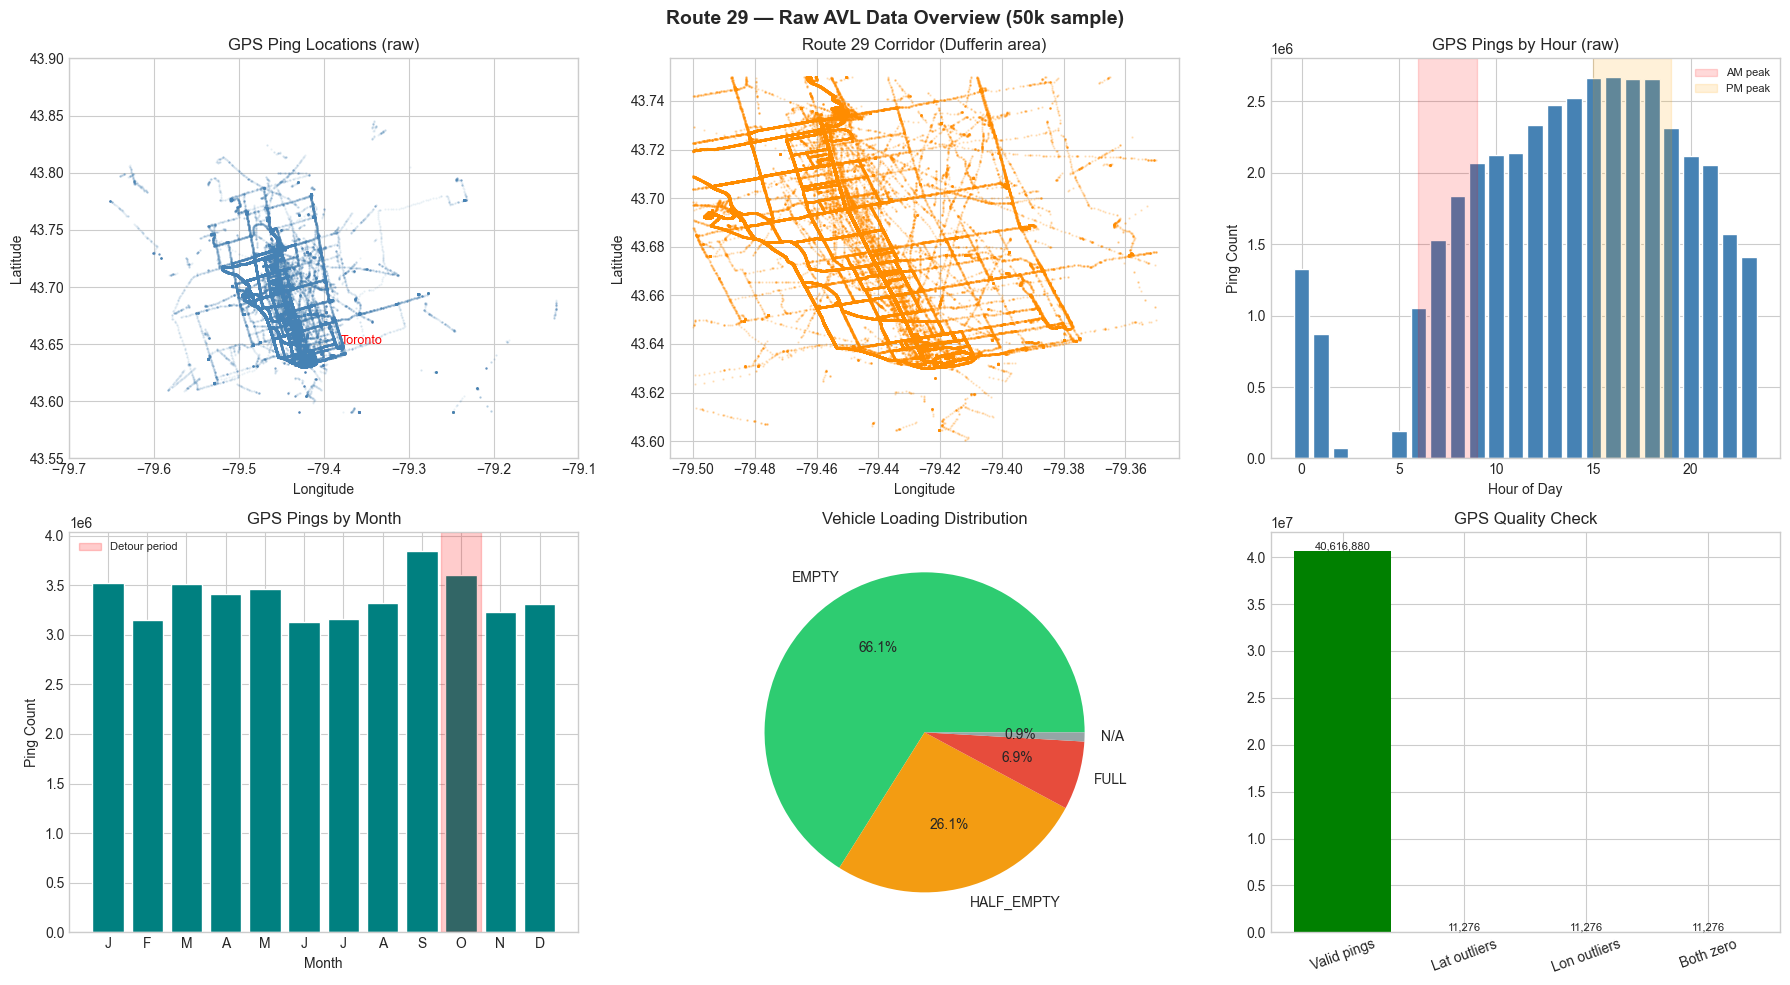

✓ Saved raw_data_overview.png


In [92]:
# ============================================================
# CELL 4 — VISUALISE RAW DATA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Route 29 — Raw AVL Data Overview (50k sample)', fontsize=14, fontweight='bold')

# ── 1. GPS scatter: Toronto map ──────────────────────────────
ax = axes[0, 0]
ax.scatter(df_sample.lon, df_sample.lat, s=0.3, alpha=0.1, color='steelblue')
ax.set_xlim(-79.7, -79.1)
ax.set_ylim(43.55, 43.90)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('GPS Ping Locations (raw)')
ax.annotate('Toronto', xy=(-79.38, 43.65), fontsize=9, color='red')

# ── 2. GPS scatter: zoomed to Route 29 corridor ──────────────
ax = axes[0, 1]
mask = (df_sample.lon.between(-79.5, -79.35)) & (df_sample.lat.between(43.6, 43.75))
ax.scatter(df_sample.loc[mask,'lon'], df_sample.loc[mask,'lat'], s=0.5, alpha=0.2, color='darkorange')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Route 29 Corridor (Dufferin area)')

# ── 3. Pings per hour of day ─────────────────────────────────
ax = axes[0, 2]
df_sample['hour'] = (df_sample.time_sec // 3600) % 24
hourly = df_sample.groupby('hour').size()
ax.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Ping Count')
ax.set_title('GPS Pings by Hour (raw)')
ax.axvspan(6, 9, alpha=0.15, color='red', label='AM peak')
ax.axvspan(15, 19, alpha=0.15, color='orange', label='PM peak')
ax.legend(fontsize=8)

# ── 4. Pings per month ───────────────────────────────────────
ax = axes[1, 0]
df_sample['month'] = df_sample.date.astype(str).str[4:6].astype(int)
monthly = df_sample.groupby('month').size()
ax.bar(monthly.index, monthly.values, color='teal', edgecolor='white')
ax.set_xlabel('Month'); ax.set_ylabel('Ping Count')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('GPS Pings by Month')
ax.axvspan(9.5, 10.5, alpha=0.2, color='red', label='Detour period')
ax.legend(fontsize=8)

# ── 5. Loading distribution ──────────────────────────────────
ax = axes[1, 1]
loading_counts = df_sample.loading.fillna('UNKNOWN').value_counts()
colors = ['#2ecc71','#f39c12','#e74c3c','#95a5a6']
ax.pie(loading_counts.values, labels=loading_counts.index, autopct='%1.1f%%',
       colors=colors[:len(loading_counts)])
ax.set_title('Vehicle Loading Distribution')

# ── 6. lat/lon outliers ──────────────────────────────────────
ax = axes[1, 2]
lat_outliers = ((df_sample.lat < 43.0) | (df_sample.lat > 44.5) | (df_sample.lat == 0)).sum()
lon_outliers = ((df_sample.lon < -80.5) | (df_sample.lon > -78.5) | (df_sample.lon == 0)).sum()
both_zero = ((df_sample.lat == 0) & (df_sample.lon == 0)).sum()
categories = ['Valid pings', 'Lat outliers', 'Lon outliers', 'Both zero']
values = [len(df_sample)-lat_outliers-lon_outliers, lat_outliers, lon_outliers, both_zero]
bars = ax.bar(categories, values, color=['green','red','orange','purple'])
ax.set_title('GPS Quality Check')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../../data/raw_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved raw_data_overview.png")

In [93]:
# ============================================================
# CELL 5 — PHASE 2: GPS OUTLIER REMOVAL
# ============================================================
# Toronto bounding box (generous)
LAT_MIN, LAT_MAX = 43.58, 43.86
LON_MIN, LON_MAX = -79.64, -79.10

con.execute("DROP TABLE IF EXISTS bronze_avl_29_clean")
con.execute(f"""
CREATE TABLE bronze_avl_29_clean AS
WITH
-- Step 1: Bounding box + datetime + loading cleanup
bounded AS (
    SELECT *,
        make_date(
            (date // 10000)::INTEGER,
            ((date % 10000) // 100)::INTEGER,
            (date % 100)::INTEGER
        ) + INTERVAL (time_sec) SECOND AS observed_at,
        CASE
            WHEN UPPER(loading) IN ('EMPTY','HALF_EMPTY','FULL') THEN UPPER(loading)
            ELSE NULL
        END AS loading_clean,
        -- Detour period flag
        (date BETWEEN {DETOUR_START} AND {DETOUR_END}) AS is_detour_period
    FROM bronze_avl_29
    WHERE lat  BETWEEN {LAT_MIN} AND {LAT_MAX}
      AND lon  BETWEEN {LON_MIN} AND {LON_MAX}
      AND lat  != 0.0
      AND lon  != 0.0
),
-- Step 2: Speed filter (remove teleportation > 120 km/h)
with_speed AS (
    SELECT *,
        LAG(lat)      OVER w AS prev_lat,
        LAG(lon)      OVER w AS prev_lon,
        LAG(time_sec) OVER w AS prev_time_sec
    FROM bounded
    WINDOW w AS (PARTITION BY vehicle_id ORDER BY date, time_sec)
),
speed_calc AS (
    SELECT *,
        CASE
          WHEN prev_lat IS NULL OR (time_sec - prev_time_sec) <= 0 THEN 0.0
          ELSE (2 * 6371.0 * ASIN(SQRT(
              POWER(SIN(RADIANS((lat - prev_lat) / 2)), 2) +
              COS(RADIANS(lat)) * COS(RADIANS(prev_lat)) *
              POWER(SIN(RADIANS((lon - prev_lon) / 2)), 2)
          ))) / ((time_sec - prev_time_sec) / 3600.0)
        END AS speed_kmh
    FROM with_speed
)
SELECT
    date, time_sec, vehicle_id, route, run,
    lat, lon, trip_id,
    loading_clean AS loading,
    observed_at,
    speed_kmh,
    is_detour_period
FROM speed_calc
WHERE speed_kmh <= 120.0
""")

n_before = con.execute("SELECT COUNT(*) FROM bronze_avl_29").fetchone()[0]
n_after  = con.execute("SELECT COUNT(*) FROM bronze_avl_29_clean").fetchone()[0]
removed  = n_before - n_after
print(f"✓ Before cleaning : {n_before:>12,}")
print(f"✓ After cleaning  : {n_after:>12,}")
print(f"  Removed         : {removed:>12,}  ({removed/n_before*100:.3f}%)")

speed_stats = con.execute("""
    SELECT 
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY speed_kmh) AS p50,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY speed_kmh) AS p95,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY speed_kmh) AS p99,
        MAX(speed_kmh) AS max_speed
    FROM bronze_avl_29_clean
""").df()
print(f"\\nSpeed distribution (km/h):")
print(speed_stats.to_string(index=False))

✓ Before cleaning :   40,639,432
✓ After cleaning  :   40,627,121
  Removed         :       12,311  (0.030%)
\nSpeed distribution (km/h):
 p50   p95   p99  max_speed
0.00 38.06 45.71     119.97


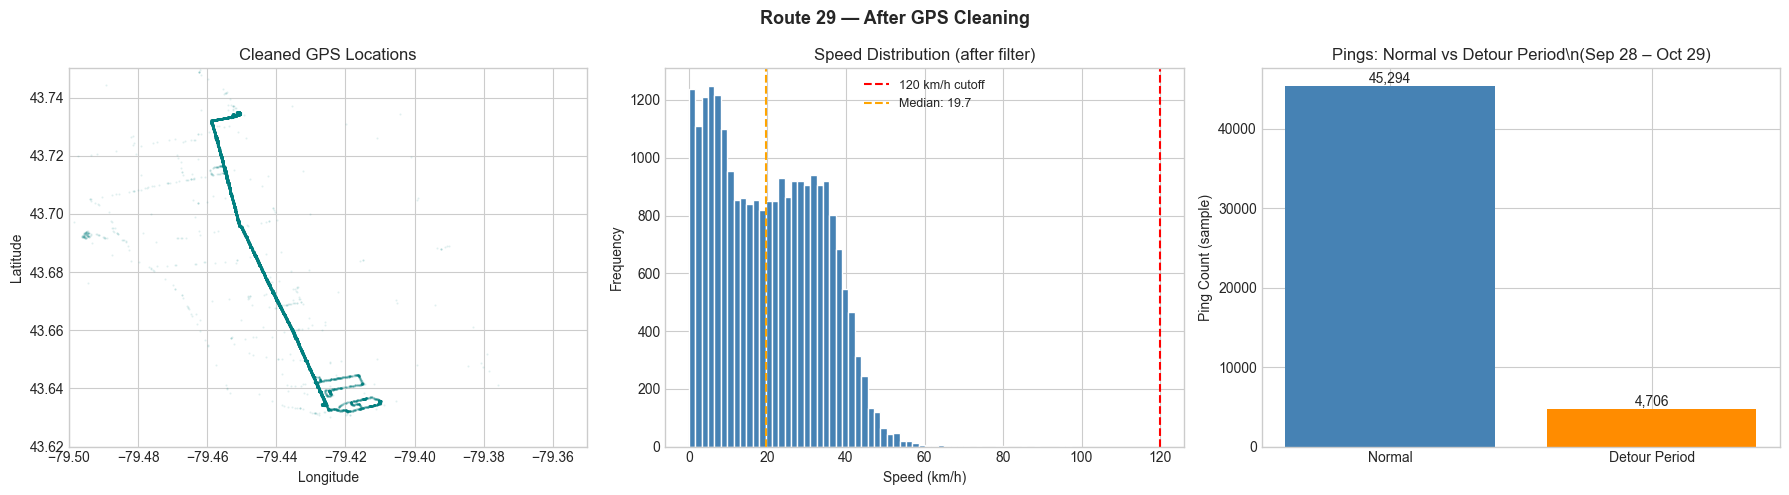

✓ Saved cleaned_data_overview.png


In [94]:
# ============================================================
# CELL 6 — VISUALISE CLEANED DATA vs RAW
# ============================================================

df_clean_sample = con.execute("""
    SELECT lat, lon, speed_kmh, 
           (time_sec // 3600) % 24 AS hour,
           is_detour_period,
           loading
    FROM bronze_avl_29_clean
    ORDER BY RANDOM() LIMIT 50000
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Route 29 — After GPS Cleaning', fontsize=13, fontweight='bold')

# ── GPS scatter after cleaning ───────────────────────────────
ax = axes[0]
ax.scatter(df_clean_sample.lon, df_clean_sample.lat, s=0.3, alpha=0.1, color='teal')
ax.set_xlim(-79.50, -79.35)
ax.set_ylim(43.62, 43.75)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Cleaned GPS Locations')

# ── Speed distribution ────────────────────────────────────────
ax = axes[1]
speeds = df_clean_sample.loc[df_clean_sample.speed_kmh > 0, 'speed_kmh']
ax.hist(speeds, bins=60, color='steelblue', edgecolor='white')
ax.axvline(120, color='red', linestyle='--', label='120 km/h cutoff')
ax.axvline(speeds.median(), color='orange', linestyle='--', label=f'Median: {speeds.median():.1f}')
ax.set_xlabel('Speed (km/h)'); ax.set_ylabel('Frequency')
ax.set_title('Speed Distribution (after filter)')
ax.legend(fontsize=9)

# ── Detour period pings ───────────────────────────────────────
ax = axes[2]
detour_counts = df_clean_sample.groupby('is_detour_period').size()
bars = ax.bar(['Normal', 'Detour Period'], 
              [detour_counts.get(False, 0), detour_counts.get(True, 0)],
              color=['steelblue', 'darkorange'])
ax.set_ylabel('Ping Count (sample)')
ax.set_title('Pings: Normal vs Detour Period\\n(Sep 28 – Oct 29)')
for bar, val in zip(bars, [detour_counts.get(False, 0), detour_counts.get(True, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../../data/cleaned_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved cleaned_data_overview.png")

In [95]:
# ============================================================
# CELL 7 — PHASE 4: LOAD GTFS STATIC FILES
# ============================================================
gtfs_tables = {
    'gtfs_stops'       : GTFS_DIR / 'stops.csv',
    'gtfs_stop_times'  : GTFS_DIR / 'stop_times.csv',
    'gtfs_trips'       : GTFS_DIR / 'trips.csv',
    'gtfs_shapes'      : GTFS_DIR / 'shapes.csv',
    'gtfs_calendar'    : GTFS_DIR / 'calendar.csv',
    'gtfs_cal_dates'   : GTFS_DIR / 'calendar_dates.csv',
    'gtfs_routes'      : GTFS_DIR / 'routes.csv',
}

for tbl, path in gtfs_tables.items():
    con.execute(f"DROP TABLE IF EXISTS {tbl}")
    con.execute(f"""
        CREATE TABLE {tbl} AS
        SELECT * FROM read_csv_auto('{path}', header=true)
    """)
    n = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  ✓ {tbl:<22} {n:>12,} rows")

print("\\nGTFS stops sample:")
print(con.execute("SELECT * FROM gtfs_stops LIMIT 3").df().to_string())
print("\\nGTFS trips sample:")
print(con.execute("""
    SELECT trip_id, route_id, service_id, trip_headsign, direction_id
    FROM gtfs_trips LIMIT 3
""").df().to_string())
print("\\nGTFS stop_times sample:")
print(con.execute("""
    SELECT trip_id, arrival_time, stop_id, stop_sequence
    FROM gtfs_stop_times LIMIT 3
""").df().to_string())

  ✓ gtfs_stops                  154,884 rows
  ✓ gtfs_stop_times           5,957,520 rows
  ✓ gtfs_trips                   43,442 rows
  ✓ gtfs_shapes                 248,428 rows
  ✓ gtfs_calendar                    66 rows
  ✓ gtfs_cal_dates                   70 rows
  ✓ gtfs_routes                      34 rows
\nGTFS stops sample:
   stop_id stop_code                              stop_name stop_desc  stop_lat  stop_lon zone_id stop_url location_type parent_station stop_timezone  wheelchair_boarding _feed_date
0    42503     16637  Warden Station at Temporary Bus Bay 2      None     43.71    -79.28    None     None          None           None          None                    1        NaT
1     4266     15504          FORT YORK BLVD AT BATHURST ST      None     43.64    -79.40    None     None          None           None          None                    1        NaT
2    42542     16122        Eglinton Ave West at Spadina Rd      None     43.70    -79.42    None     None          No

In [96]:
# ============================================================
# CELL 8 — GTFS EXPLORATION: ROUTE 29
# ============================================================

# How many Route 29 trips and stops in GTFS?
rt29_summary = con.execute("""
    SELECT 
        COUNT(DISTINCT t.trip_id) AS total_trips,
        COUNT(DISTINCT st.stop_id) AS unique_stops,
        COUNT(*) AS total_stop_times,
        MIN(t.direction_id) AS dir_min,
        MAX(t.direction_id) AS dir_max
    FROM gtfs_trips t
    JOIN gtfs_stop_times st ON st.trip_id::VARCHAR = t.trip_id::VARCHAR
    WHERE t.route_id::VARCHAR = '29'
""").df()
print("Route 29 GTFS summary:")
print(rt29_summary.to_string(index=False))

# Sample of Route 29 stops
rt29_stops = con.execute("""
    SELECT DISTINCT s.stop_id, s.stop_name, s.stop_lat, s.stop_lon
    FROM gtfs_stops s
    JOIN gtfs_stop_times st ON st.stop_id::VARCHAR = s.stop_id::VARCHAR
    JOIN gtfs_trips t ON t.trip_id::VARCHAR = st.trip_id::VARCHAR
    WHERE t.route_id::VARCHAR = '29'
    ORDER BY s.stop_id::INTEGER
""").df()
print(f"\\nRoute 29 stops ({len(rt29_stops)} total):")
print(rt29_stops.head(10).to_string(index=False))

# Trips that exist in BOTH AVL and GTFS
match_summary = con.execute("""
    SELECT 
        COUNT(DISTINCT a.trip_id) AS avl_unique_trips,
        (SELECT COUNT(DISTINCT trip_id::INTEGER) 
         FROM gtfs_trips WHERE route_id::VARCHAR = '29') AS gtfs_rt29_trips,
        COUNT(DISTINCT CASE WHEN g.trip_id IS NOT NULL THEN a.trip_id END) AS matching_trips
    FROM (SELECT DISTINCT trip_id FROM bronze_avl_29_clean) a
    LEFT JOIN (
        SELECT DISTINCT trip_id::INTEGER AS trip_id 
        FROM gtfs_trips WHERE route_id::VARCHAR = '29'
    ) g ON g.trip_id = a.trip_id
""").df()
print(f"\\nTrip ID match summary (AVL ↔ GTFS Route 29):")
print(match_summary.to_string(index=False))

Route 29 GTFS summary:
 total_trips  unique_stops  total_stop_times  dir_min  dir_max
       19148          9535           3629671        0        1
\nRoute 29 stops (9597 total):
 stop_id                                  stop_name  stop_lat  stop_lon
       1         Millwood Rd at McRae Dr South Side     43.70    -79.37
       2                 Bathurst St at Horsham Ave     43.77    -79.44
       3           Royal York Rd at King Georges Rd     43.65    -79.51
       4            Finch Ave West at Driftwood Ave     43.76    -79.51
       5   Lawrence Ave East at Wanless Cres (West)     43.73    -79.39
       7               Kennedy Rd at Huntingwood Dr     43.80    -79.29
       8 Shorncliffe Ave at Newbridge Rd South Side     43.63    -79.54
       9                     Warden Ave at Tower Dr     43.75    -79.30
      10                 Thirtieth St at Alhena Ave     43.60    -79.53
      11           Birchmount Rd at Harvest Moon Dr     43.82    -79.32
\nTrip ID match summary (AVL

In [97]:
# ============================================================
# CELL 9 — PHASES 5–7: MATCH GPS → STOPS → COMPUTE DELAYS
# ============================================================
# STRATEGY (fixed):
#   For each (vehicle_id, trip_id, stop_id):
#     1. Join AVL pings to GTFS stops via trip_id (already matched!)
#     2. Time-window filter: only consider pings within ±15 min of scheduled time
#     3. Distance sanity check: ping must be within 500m of the stop
#     4. ROW_NUMBER to pick the single ping closest in time to scheduled arrival
#     5. delay_seconds = actual time_sec - scheduled_sec

print("Building silver_stop_events_29 — this may take 1–5 minutes for 40M rows...")

con.execute("DROP TABLE IF EXISTS silver_stop_events_29")
con.execute("""
CREATE TABLE silver_stop_events_29 AS
WITH

-- ── Step A: Route 29 trips in GTFS ──────────────────────────
rt29_trips AS (
    SELECT DISTINCT trip_id::INTEGER AS trip_id
    FROM gtfs_trips
    WHERE route_id::VARCHAR = '29'
),

-- ── Step B: All stops for those trips with coordinates ───────
-- Converts scheduled arrival_time (HH:MM:SS, may exceed 24h) → seconds
rt29_stop_times AS (
    SELECT
        st.trip_id::INTEGER                                AS trip_id,
        st.stop_id::INTEGER                                AS stop_id,
        st.stop_sequence::INTEGER                          AS stop_sequence,
        (
          SPLIT_PART(st.arrival_time, ':', 1)::INTEGER * 3600 +
          SPLIT_PART(st.arrival_time, ':', 2)::INTEGER * 60  +
          SPLIT_PART(st.arrival_time, ':', 3)::INTEGER
        )                                                  AS scheduled_sec,
        st.arrival_time,
        s.stop_lat::DOUBLE                                 AS stop_lat,
        s.stop_lon::DOUBLE                                 AS stop_lon,
        s.stop_name
    FROM gtfs_stop_times st
    JOIN gtfs_stops s
      ON s.stop_id::VARCHAR = st.stop_id::VARCHAR
    WHERE st.trip_id::INTEGER IN (SELECT trip_id FROM rt29_trips)
),

-- ── Step C: AVL pings for Route 29 trips only ────────────────
avl_rt29 AS (
    SELECT *
    FROM bronze_avl_29_clean
    WHERE trip_id IN (SELECT trip_id FROM rt29_trips)
),

-- ── Step D: Join AVL to stops — time-window pre-filter ───────
-- For 40M pings × avg ~50 stops/trip this would explode without the window.
-- The ±900-second window limits each ping to only the 1–2 nearby stops.
candidates AS (
    SELECT
        avl.date,
        avl.time_sec,
        avl.observed_at,
        avl.vehicle_id,
        avl.route,
        avl.run,
        avl.trip_id,
        avl.lat                                           AS avl_lat,
        avl.lon                                           AS avl_lon,
        avl.loading,
        avl.is_detour_period,
        sts.stop_id,
        sts.stop_sequence,
        sts.scheduled_sec,
        sts.arrival_time                                  AS scheduled_time,
        sts.stop_lat,
        sts.stop_lon,
        sts.stop_name,
        -- Haversine distance in metres
        2 * 6371000.0 * ASIN(SQRT(
            POWER(SIN(RADIANS((avl.lat - sts.stop_lat) / 2.0)), 2) +
            COS(RADIANS(avl.lat)) * COS(RADIANS(sts.stop_lat)) *
            POWER(SIN(RADIANS((avl.lon - sts.stop_lon) / 2.0)), 2)
        ))                                                AS dist_to_stop_m,
        ABS(avl.time_sec - sts.scheduled_sec)            AS time_diff_sec
    FROM avl_rt29 avl
    JOIN rt29_stop_times sts
      ON sts.trip_id = avl.trip_id
     -- Time-window pre-filter: ±15 minutes of scheduled arrival
     AND ABS(avl.time_sec - sts.scheduled_sec) < 900
),

-- ── Step E: Distance filter + rank by time proximity ─────────
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY vehicle_id, trip_id, stop_id
            ORDER BY time_diff_sec ASC
        ) AS rn
    FROM candidates
    WHERE dist_to_stop_m <= 500.0  -- within 500 m of stop
),

-- ── Step F: Keep the single best ping per stop-visit ─────────
stop_events AS (
    SELECT * FROM ranked WHERE rn = 1
)

SELECT
    date,
    observed_at,
    vehicle_id,
    route,
    run,
    trip_id,
    stop_id,
    stop_sequence,
    stop_name,
    avl_lat,
    avl_lon,
    stop_lat,
    stop_lon,
    ROUND(dist_to_stop_m, 1)           AS dist_to_stop_m,
    loading,
    is_detour_period,
    time_sec                           AS actual_sec,
    scheduled_sec,
    scheduled_time,
    -- DELAY: positive = late, negative = early
    (time_sec - scheduled_sec)         AS delay_seconds
FROM stop_events
ORDER BY observed_at
""")

n = con.execute("SELECT COUNT(*) FROM silver_stop_events_29").fetchone()[0]
print(f"\\n✓ silver_stop_events_29: {n:,} stop-arrival events")

print("\\nDelay distribution (seconds):")
print(con.execute("""
    SELECT
        ROUND(AVG(delay_seconds), 0)                               AS mean_delay,
        ROUND(MEDIAN(delay_seconds), 0)                            AS median_delay,
        ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP 
              (ORDER BY delay_seconds), 0)                         AS p05_delay,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP 
              (ORDER BY delay_seconds), 0)                         AS p95_delay,
        MIN(delay_seconds)                                         AS min_delay,
        MAX(delay_seconds)                                         AS max_delay,
        SUM(CASE WHEN delay_seconds > 0 THEN 1 ELSE 0 END) * 100.0
            / COUNT(*)                                             AS pct_late
    FROM silver_stop_events_29
""").df().to_string(index=False))

Building silver_stop_events_29 — this may take 1–5 minutes for 40M rows...
\n✓ silver_stop_events_29: 0 stop-arrival events
\nDelay distribution (seconds):
 mean_delay  median_delay  p05_delay  p95_delay  min_delay  max_delay  pct_late
        NaN           NaN        NaN        NaN       <NA>       <NA>       NaN


In [98]:
# 1. Check trip_id types and samples
print("=== AVL trip_id ===")
print(con.execute("SELECT typeof(trip_id) AS t, trip_id FROM bronze_avl_29_clean LIMIT 5").df())

print("\n=== GTFS trip_id ===")
print(con.execute("SELECT typeof(trip_id) AS t, trip_id FROM gtfs_trips WHERE route_id::VARCHAR = '29' LIMIT 5").df())

# 2. Check route_id values containing '29'
print("\n=== route_id values like 29 ===")
print(con.execute("SELECT DISTINCT route_id FROM gtfs_trips WHERE route_id::VARCHAR LIKE '%29%'").df())

# 3. Trip_id overlap (cast both to VARCHAR for safety)
print("\n=== Trip ID overlap ===")
print(con.execute("""
    SELECT COUNT(DISTINCT a.trip_id) AS matching_trips
    FROM bronze_avl_29_clean a
    WHERE a.trip_id::VARCHAR IN (
        SELECT trip_id::VARCHAR FROM gtfs_trips WHERE route_id::VARCHAR = '29'
    )
""").df())

# 4. Time scales
print("\n=== AVL time_sec range ===")
print(con.execute("SELECT MIN(time_sec) AS min_t, MAX(time_sec) AS max_t FROM bronze_avl_29_clean").df())

print("\n=== GTFS scheduled_sec range ===")
print(con.execute("""
    SELECT MIN(s) AS min_s, MAX(s) AS max_s FROM (
        SELECT SPLIT_PART(arrival_time,':',1)::INT*3600 
             + SPLIT_PART(arrival_time,':',2)::INT*60 
             + SPLIT_PART(arrival_time,':',3)::INT AS s
        FROM gtfs_stop_times st 
        JOIN gtfs_trips t ON t.trip_id = st.trip_id 
        WHERE t.route_id::VARCHAR = '29'
    )
""").df())

# 5. NULL trip_ids
print("\n=== NULL trip_ids in AVL ===")
print(con.execute("SELECT COUNT(*) AS total, COUNT(trip_id) AS non_null_trip_id FROM bronze_avl_29_clean").df())

=== AVL trip_id ===
         t   trip_id
0  INTEGER  52289539
1  INTEGER  52289539
2  INTEGER  52289539
3  INTEGER  52289539
4  INTEGER  52289539

=== GTFS trip_id ===
        t    trip_id
0  BIGINT  153519070
1  BIGINT  148337040
2  BIGINT  152942050
3  BIGINT  148393080
4  BIGINT  152927050

=== route_id values like 29 ===
   route_id
0        29

=== Trip ID overlap ===
   matching_trips
0               1

=== AVL time_sec range ===
   min_t  max_t
0      0  86399

=== GTFS scheduled_sec range ===
   min_s   max_s
0   7500  110273

=== NULL trip_ids in AVL ===
      total  non_null_trip_id
0  40627121          40627121


In [ ]:
# ============================================================
# PHASES 5–7: MATCH GPS → STOPS → DELAYS  (Correct approach)
# ============================================================
# AVL trip_id (integer) ≠ GTFS trip_id (string like "29-MCN25SU-...")
# They are DIFFERENT ID systems — cannot join directly.
#
# CORRECT STRATEGY: Time + Space matching
#   For each AVL ping near a Route 29 stop:
#     1. Get all Route 29 stops from GTFS (spatial index)
#     2. Find pings within 200m of any stop
#     3. For each (vehicle, date, stop), find the ping closest in time
#        to each scheduled service on that stop that day
#     4. delay = actual arrival time - scheduled arrival time

print("Building silver_stop_events_29 — time+space matching...")
print("(may take 3–8 min for 40M rows)")

con.execute("DROP TABLE IF EXISTS silver_stop_events_29")
con.execute(f"""
CREATE TABLE silver_stop_events_29 AS
WITH

-- ── A. Route 29 stops with coordinates ──────────────────────
rt29_stops AS (
    SELECT DISTINCT
        s.stop_id::INTEGER  AS stop_id,
        s.stop_name,
        s.stop_lat::DOUBLE  AS stop_lat,
        s.stop_lon::DOUBLE  AS stop_lon
    FROM gtfs_stops s
    JOIN gtfs_stop_times st ON st.stop_id::VARCHAR = s.stop_id::VARCHAR
    JOIN gtfs_trips t       ON t.trip_id           = st.trip_id
    WHERE t.route_id::VARCHAR = '29'
),

-- ── B. Scheduled arrivals at Route 29 stops ─────────────────
-- One row per (trip, stop, scheduled_time)
rt29_schedule AS (
    SELECT
        t.trip_id                                           AS gtfs_trip_id,
        t.direction_id::INTEGER                             AS direction_id,
        st.stop_id::INTEGER                                 AS stop_id,
        st.stop_sequence::INTEGER                           AS stop_sequence,
        st.arrival_time,
        (
          SPLIT_PART(st.arrival_time, ':', 1)::INTEGER * 3600 +
          SPLIT_PART(st.arrival_time, ':', 2)::INTEGER * 60  +
          SPLIT_PART(st.arrival_time, ':', 3)::INTEGER
        )                                                   AS scheduled_sec
    FROM gtfs_stop_times st
    JOIN gtfs_trips t ON t.trip_id = st.trip_id
    WHERE t.route_id::VARCHAR = '29'
),

-- ── C. AVL pings within 300m of ANY Route 29 stop ───────────
-- This reduces 40M rows to only pings near the route
avl_near_stops AS (
    SELECT
        avl.date,
        avl.time_sec,
        avl.observed_at,
        avl.vehicle_id,
        avl.route,
        avl.run,
        avl.trip_id         AS avl_trip_id,
        avl.lat             AS avl_lat,
        avl.lon             AS avl_lon,
        avl.loading,
        avl.is_detour_period,
        rs.stop_id,
        rs.stop_name,
        rs.stop_lat,
        rs.stop_lon,
        -- Haversine distance in metres
        2 * 6371000.0 * ASIN(SQRT(
            POWER(SIN(RADIANS((avl.lat - rs.stop_lat) / 2.0)), 2) +
            COS(RADIANS(avl.lat)) * COS(RADIANS(rs.stop_lat)) *
            POWER(SIN(RADIANS((avl.lon - rs.stop_lon) / 2.0)), 2)
        ))                  AS dist_to_stop_m
    FROM bronze_avl_29_clean avl
    CROSS JOIN rt29_stops rs
    -- Only route 29 vehicles
    WHERE avl.route = 29
),

-- ── D. Keep only pings within 300m of a stop ────────────────
near_stop_pings AS (
    SELECT * FROM avl_near_stops
    WHERE dist_to_stop_m <= 300.0
),

-- ── E. For each (vehicle, date, stop) join to scheduled trips
-- Match ping time to scheduled arrival within ±600 seconds
candidates AS (
    SELECT
        p.*,
        sch.gtfs_trip_id,
        sch.direction_id,
        sch.stop_sequence,
        sch.scheduled_sec,
        sch.arrival_time                                    AS scheduled_time,
        ABS(p.time_sec - sch.scheduled_sec)                AS time_diff_sec
    FROM near_stop_pings p
    JOIN rt29_schedule sch
      ON  sch.stop_id = p.stop_id
      AND ABS(p.time_sec - sch.scheduled_sec) < 600        -- ±10 min window
),

-- ── F. For each (vehicle, gtfs_trip, stop) keep closest ping ─
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY vehicle_id, gtfs_trip_id, stop_id
            ORDER BY time_diff_sec ASC
        ) AS rn
    FROM candidates
),

stop_events AS (SELECT * FROM ranked WHERE rn = 1)

SELECT
    date,
    observed_at,
    vehicle_id,
    route,
    run,
    avl_trip_id,
    gtfs_trip_id,
    stop_id,
    stop_sequence,
    stop_name,
    direction_id,
    avl_lat,
    avl_lon,
    stop_lat,
    stop_lon,
    ROUND(dist_to_stop_m, 1)    AS dist_to_stop_m,
    loading,
    is_detour_period,
    time_sec                    AS actual_sec,
    scheduled_sec,
    scheduled_time,
    (time_sec - scheduled_sec)  AS delay_seconds
FROM stop_events
ORDER BY observed_at
""")

n = con.execute("SELECT COUNT(*) FROM silver_stop_events_29").fetchone()[0]
print(f"\\n✓ silver_stop_events_29: {n:,} stop-arrival events")

if n > 0:
    print("\\nDelay distribution (seconds):")
    print(con.execute("""
        SELECT
            ROUND(AVG(delay_seconds), 0)                            AS mean_delay,
            ROUND(MEDIAN(delay_seconds), 0)                         AS median_delay,
            ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP
                  (ORDER BY delay_seconds), 0)                      AS p05_delay,
            ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP
                  (ORDER BY delay_seconds), 0)                      AS p95_delay,
            MIN(delay_seconds)                                      AS min_delay,
            MAX(delay_seconds)                                      AS max_delay,
            ROUND(SUM(CASE WHEN delay_seconds > 0 THEN 1 ELSE 0 END)
                * 100.0 / COUNT(*), 1)                              AS pct_late
        FROM silver_stop_events_29
    """).df().to_string(index=False))
else:
    # Deep diagnostics if still 0
    print("\\n⚠ Still 0 — running diagnostics...")
    print("AVL route 29 pings:", con.execute(
        "SELECT COUNT(*) FROM bronze_avl_29_clean WHERE route=29").fetchone()[0])
    print("GTFS route 29 stops:", con.execute("""
        SELECT COUNT(DISTINCT s.stop_id) FROM gtfs_stops s
        JOIN gtfs_stop_times st ON st.stop_id::VARCHAR=s.stop_id::VARCHAR
        JOIN gtfs_trips t ON t.trip_id=st.trip_id
        WHERE t.route_id::VARCHAR='29'""").fetchone()[0])
    print("Sample AVL lat/lon for route 29:")
    print(con.execute("""
        SELECT lat, lon, time_sec FROM bronze_avl_29_clean
        WHERE route=29 LIMIT 5""").df().to_string(index=False))
    print("Sample GTFS stop coords for route 29:")
    print(con.execute("""
        SELECT DISTINCT s.stop_id, s.stop_lat, s.stop_lon
        FROM gtfs_stops s
        JOIN gtfs_stop_times st ON st.stop_id::VARCHAR=s.stop_id::VARCHAR
        JOIN gtfs_trips t ON t.trip_id=st.trip_id
        WHERE t.route_id::VARCHAR='29' LIMIT 5""").df().to_string(index=False))

Building silver_stop_events_29 — time+space matching...
(may take 3–8 min for 40M rows)


In [ ]:
# ============================================================
# CELL 10 — VISUALISE STOP-ARRIVAL EVENTS
# ============================================================

df_silver = con.execute("""
    SELECT observed_at, delay_seconds, dist_to_stop_m, stop_name,
           stop_id, vehicle_id, is_detour_period, loading,
           EXTRACT(HOUR FROM observed_at)::INTEGER AS hour,
           EXTRACT(DOW  FROM observed_at)::INTEGER AS dow,
           EXTRACT(MONTH FROM observed_at)::INTEGER AS month
    FROM silver_stop_events_29
""").df()

print(f"Silver layer shape: {df_silver.shape}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Route 29 — Stop Arrival Events', fontsize=14, fontweight='bold')

# ── 1. Delay distribution ────────────────────────────────────
ax = axes[0, 0]
delay_clip = df_silver.delay_seconds.clip(-600, 1800)
ax.hist(delay_clip, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='green', linewidth=2, label='On time')
ax.axvline(delay_clip.median(), color='orange', linewidth=2,
           linestyle='--', label=f'Median: {delay_clip.median():.0f}s')
ax.set_xlabel('Delay (seconds)'); ax.set_ylabel('Count')
ax.set_title('Delay Distribution\\n(clipped -600s to +1800s)')
ax.legend(fontsize=9)

# ── 2. Delay by hour of day ──────────────────────────────────
ax = axes[0, 1]
hourly_delay = df_silver.groupby('hour')['delay_seconds'].median()
ax.bar(hourly_delay.index, hourly_delay.values / 60, color='steelblue', edgecolor='white')
ax.axhline(0, color='green', linewidth=1)
ax.axvspan(6, 9, alpha=0.15, color='red', label='AM peak')
ax.axvspan(15, 19, alpha=0.15, color='orange', label='PM peak')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Median Delay (min)')
ax.set_title('Median Delay by Hour')
ax.legend(fontsize=8)

# ── 3. Delay by day of week ──────────────────────────────────
ax = axes[0, 2]
days = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
dow_delay = df_silver.groupby('dow')['delay_seconds'].median()
colors_dow = ['#e74c3c' if d in [0,6] else '#3498db' for d in dow_delay.index]
ax.bar([days[d] for d in dow_delay.index], dow_delay.values / 60,
       color=colors_dow, edgecolor='white')
ax.axhline(0, color='green', linewidth=1)
ax.set_xlabel('Day of Week'); ax.set_ylabel('Median Delay (min)')
ax.set_title('Median Delay by Day')

# ── 4. Events by month ───────────────────────────────────────
ax = axes[1, 0]
monthly = df_silver.groupby('month').size()
ax.bar(monthly.index, monthly.values, color='teal', edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.axvspan(9.5, 10.5, alpha=0.2, color='red', label='Detour')
ax.set_xlabel('Month'); ax.set_ylabel('Stop Events')
ax.set_title('Stop Events per Month')
ax.legend(fontsize=8)

# ── 5. Detour vs Non-detour delay comparison ──────────────────
ax = axes[1, 1]
detour_data   = df_silver.loc[df_silver.is_detour_period, 'delay_seconds'].clip(-600, 1800)
normal_data   = df_silver.loc[~df_silver.is_detour_period,'delay_seconds'].clip(-600, 1800)
ax.hist(normal_data / 60, bins=80, alpha=0.6, label=f'Normal (n={len(normal_data):,})', 
        color='steelblue', density=True)
ax.hist(detour_data / 60, bins=80, alpha=0.6, label=f'Detour (n={len(detour_data):,})',
        color='darkorange', density=True)
ax.axvline(0, color='green', linewidth=1.5)
ax.set_xlabel('Delay (minutes)'); ax.set_ylabel('Density')
ax.set_title('Delay: Normal vs Detour Period')
ax.legend(fontsize=9)

# ── 6. Distance to stop (match quality) ──────────────────────
ax = axes[1, 2]
ax.hist(df_silver.dist_to_stop_m, bins=50, color='purple', edgecolor='white', alpha=0.8)
ax.axvline(df_silver.dist_to_stop_m.median(), color='red', linestyle='--',
           label=f'Median: {df_silver.dist_to_stop_m.median():.0f}m')
ax.set_xlabel('Distance to Stop (m)'); ax.set_ylabel('Count')
ax.set_title('GPS-to-Stop Match Distance\\n(≤500m filter applied)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../../data/silver_stop_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved silver_stop_events.png")